In [3]:
import matplotlib.pyplot as plt;import apple;import numpy as np

In [2]:
hexagon=apple.jit('''
λ𝜃.
{
  unzip ← [((->1)'x,(->2)'x)];
  hex ⟜ ⟨(3%2,√3%2),(0,√3),(_3%2,√3%2),(_3%2,_(√3)%2),(0,_(√3)),(3%2,_(√3)%2)⟩;
  tie ← [{.x⊳x];
  rot ← λ𝜃.λ(𝑥,𝑦). (𝑥*cos.𝜃-𝑦*sin.𝜃,𝑥*sin.𝜃+𝑦*cos.𝜃);
  -- T ← λk.λl.λ(x,y). (x+3*k+(3%2)*l,y+(√3%2)*l);
  unzip (tie (rot 𝜃'hex))
}
''')
hex_x,hex_y=hexagon(np.pi/5)

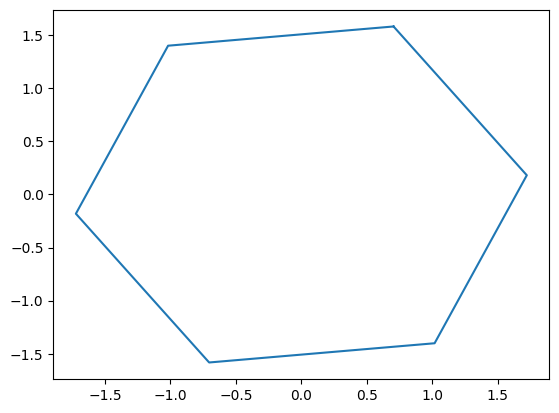

In [3]:
plt.plot(hex_x,hex_y)

In [5]:
c=apple.jit('''
{ plus ← λ(a,b).λ(c,d). (a+c,b+d)
; div ← λ(a,b).λ(c,d). {n ⟜ c^2+d^2; ((a*b+c*d)%n,(b*c-a*d)%n)}
; one ⟜ (1,0)
; f ← z ↦ plus one (div one z)
; f`{0} ((frange _5 5 11) [(x,y)]⊗ (frange _5 5 11))
}
''')

In [7]:
print(c)

<fn : Arr (11 × 11) (float * float)>


In [17]:
def u(x):
    p1=np.vectorize(lambda x: x[0])
    p2=np.vectorize(lambda x: x[1])
    return (p1(x),p2(x))

In [18]:
inv=apple.jit('''
{ conj ← λ(a,b). (a,_b)
; div ← λ(a,b).λ(c,d). {n ⟜ c^2+d^2; ((a*b+c*d)%n,(b*c-a*d)%n)}
; inv ← z ↦ div (1,0) (conj z)
; grid ⟜ (frange 0.25 0.75 15) [(x,y)]⊗ (frange _0.25 0.25 15)
; inv`{0} grid
}
''')

In [19]:
xs,ys=u(inv())

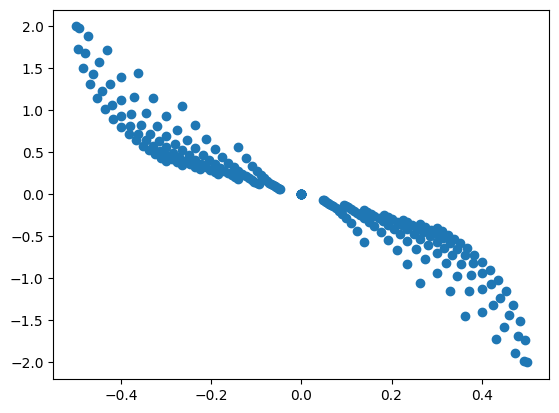

In [20]:
plt.scatter(xs,ys)